In [65]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap


# load dataset
df = pd.read_csv('student_productivity_distraction_dataset_20000.csv')



### Research questions: 

1. Research Question 1: What are the primary behavioral factors that predict student productivity?
2. Research Question 2: Can we accurately predict a student's productivity score based on their lifestyle habits?
3. Research Question 3: What specific behavioral changes would most significantly improve a student's productivity?


following the flow of these research questions, we will cover 3 different phases:
1. Exploratory data analysis
2. Modelling
3. Inference

We will not only investigate factors that influence student productivity, they will also be applied to an inferential case which will lead to actionable insights.



### PHASE 1: EXPLORATORY DATA ANALYSIS



In [30]:
# 1.1 Dataset Overview
print("DATASET OVERVIEW")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst few rows:\n{df.head()}")

DATASET OVERVIEW
Shape: (20000, 18)

Data types:
student_id                 int64
age                        int64
gender                    object
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object

First few rows:
   student_id  age  gender  study_hours_per_day  sleep_hours  \
0           1   23  Female                 4.35         3.63   
1           2   20    Male                 6.14         6.58   
2           3   29  Female                 4.98         3.26   
3           4   27  Female                 3.19         4.58   
4     

Our dataset contains 20000 observations in total with in total 18 columns, this mainly constitutes numerical features with the exception of 'Gender'. Looking at the first 5 columns of the dataset gives us an initial idea of the data we are working with, but we need to investigate the dataset further.

In [31]:
# 1.2 Basic Statistics
print("\n\nBASIC STATISTICS")
print(df.describe().round(2))



BASIC STATISTICS
       student_id       age  study_hours_per_day  sleep_hours  \
count    20000.00  20000.00             20000.00     20000.00   
mean     10000.50     23.01                 5.25         6.52   
std       5773.65      3.75                 2.74         2.03   
min          1.00     17.00                 0.50         3.00   
25%       5000.75     20.00                 2.90         4.77   
50%      10000.50     23.00                 5.25         6.51   
75%      15000.25     26.00                 7.64         8.31   
max      20000.00     29.00                10.00        10.00   

       phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
count           20000.00            20000.00       20000.00      20000.00   
mean                6.25                4.00           2.99          2.99   
std                 3.31                2.31           1.73          1.73   
min                 0.50                0.00           0.00          0.00   
25%       

The .describe() gives us an initial overview of some basic statistics and distribution of columns. We check for any outliers or impossible values, such as negative values in the case for Age for example. At first glance our dataset looks clean.

In [32]:
# 1.3 Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    for col, count in missing.items():
        pct = (count / len(df)) * 100
        print(f"{col}: {count} ({pct:.1f}%)")
else:
    print("No missing values found ✓")

No missing values found ✓


In [33]:
# 1.4 Check for Duplicates
print("DUPLICATE ROWS")
duplicates = df.duplicated().sum()
print(f"Total duplicates: {duplicates}")
df_clean = df.drop_duplicates()
print(f"Cleaned shape: {df_clean.shape}")

DUPLICATE ROWS
Total duplicates: 0
Cleaned shape: (20000, 18)


There are no missing or duplicate values in our dataset.

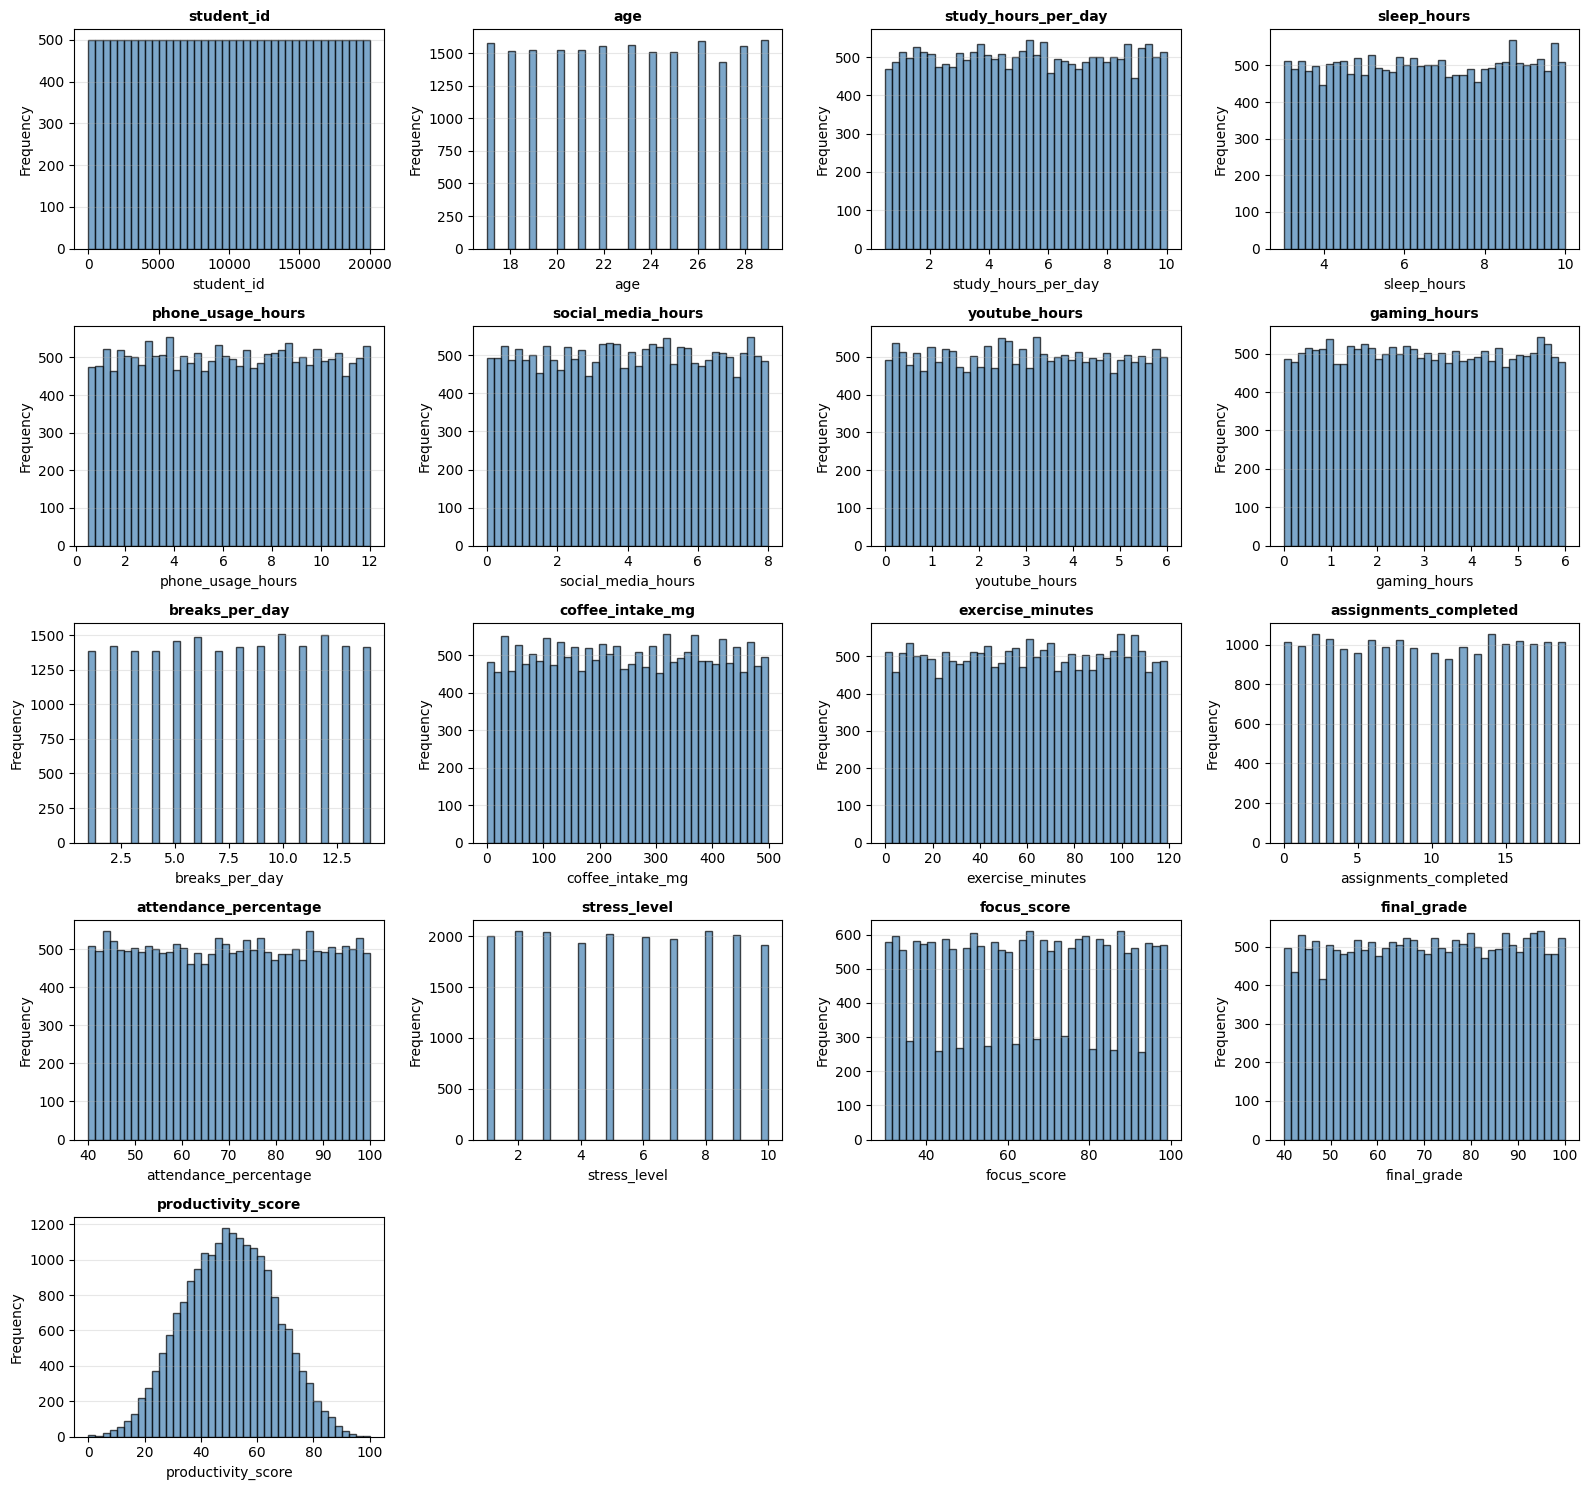

In [34]:
# 1.5 Distribution of Numerical Features
# Get numerical columns
numerical = df.select_dtypes(include=[np.number]).columns

# Create subplots
n_cols = 4
n_rows = (len(numerical) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

# Plot histogram for each numerical column
for idx, col in enumerate(numerical):
    ax = axes[idx]
    ax.hist(df[col], bins=40, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3, axis='y')

# Hide empty subplots
for idx in range(len(numerical), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [52]:
# 1.6 Outlier Detection
print("\n\nOUTLIER DETECTION (IQR Method)")
for col in numerical:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = (outliers/len(df)*100)
    print(f"{col} - {outliers} outliers ({pct:.2f}%)")



OUTLIER DETECTION (IQR Method)
student_id - 0 outliers (0.00%)
age - 0 outliers (0.00%)
study_hours_per_day - 0 outliers (0.00%)
sleep_hours - 0 outliers (0.00%)
phone_usage_hours - 0 outliers (0.00%)
social_media_hours - 0 outliers (0.00%)
youtube_hours - 0 outliers (0.00%)
gaming_hours - 0 outliers (0.00%)
breaks_per_day - 0 outliers (0.00%)
coffee_intake_mg - 0 outliers (0.00%)
exercise_minutes - 0 outliers (0.00%)
assignments_completed - 0 outliers (0.00%)
attendance_percentage - 0 outliers (0.00%)
stress_level - 0 outliers (0.00%)
focus_score - 0 outliers (0.00%)
final_grade - 0 outliers (0.00%)
productivity_score - 18 outliers (0.09%)


Our variables seem to be distributed very uniformly, with no apparent outliers. Our target variable 'productivity score' has a nice bell curve.

In [ ]:
def analyze_productivity_factors(df):
    """
    Analyze the relationship between behavioral factors and student productivity.
    
    This function calculates correlation coefficients between all numerical features
    and the target variable (productivity_score) to identify which factors most
    strongly influence student productivity.
    
    Parameters:
    
    df : pandas.DataFrame
        Input dataframe containing student data with columns for behavioral factors
        and productivity_score.
    
    Returns:
    
    pandas.Series
        Correlation coefficients sorted in descending order, showing the strength
        of relationship between each feature and productivity_score.
    
    
    """
    numerical = df.select_dtypes(include=[np.number]).columns
    correlations = df[numerical].corr()['productivity_score'].sort_values(ascending=False)
    return correlations



In [85]:
# 1.7 correlation with target variable

print("\n\nANALYZING PRODUCTIVITY FACTORS")
correlations = analyze_productivity_factors(df)
print(correlations)



ANALYZING PRODUCTIVITY FACTORS
productivity_score       1.000000
study_hours_per_day      0.732777
focus_score              0.411366
sleep_hours              0.340902
attendance_percentage    0.176107
student_id               0.012579
coffee_intake_mg         0.010190
exercise_minutes         0.002892
final_grade              0.001954
social_media_hours       0.001285
gaming_hours             0.000685
youtube_hours           -0.000224
assignments_completed   -0.001757
age                     -0.005423
breaks_per_day          -0.005836
stress_level            -0.197128
phone_usage_hours       -0.326650
Name: productivity_score, dtype: float64


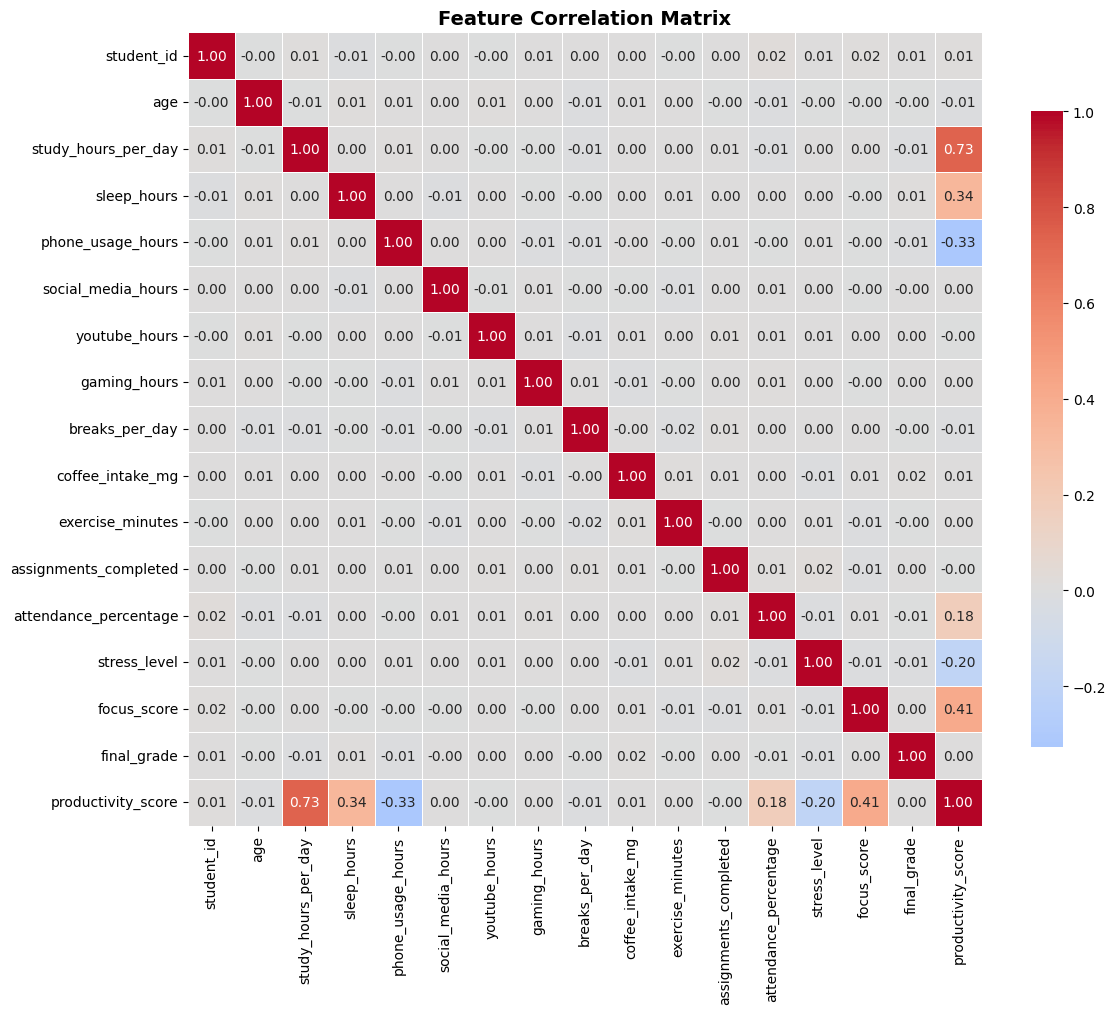

In [36]:
# Create correlation matrix
corr_matrix = df[numerical].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

Looking at the correlation between the features and our target variable we get an initial idea of which features could potentially ne influential in predicting our target variable. We can see that especiaaly:

1. study_hours_per_day      
2. focus_score              
3. sleep_hours

have a high correlation with the target variable.

We also check the correlation between the features themselves to see if multicollinearity might be a potential issue, since random forest models tend to struggle with this. Apart from correlation with the target variable, there seems to be no correlation between the predictor variables themselves.

### PHASE 2: Model training

In [39]:
# 2.1 Prepare Data

# Drop non-feature columns
features_to_drop = ['student_id', 'gender', 'productivity_score']
X = df_clean.drop(columns=features_to_drop)
y = df_clean['productivity_score']

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]}")
print(f"Feature list: {X.columns.tolist()}")


Features: 15
Samples:  20000
Feature list: ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade']


In [40]:
# 2.2 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")


Train set: 16000 samples
Test set:  4000 samples


In [ ]:
# 2.3 Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 2.4 Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

Training Random Forest...


In [44]:
# 2.5 Evaluate Model
# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

# Display results
print("MODEL PERFORMANCE")
print(f"Train R²:  {train_r2:.4f}")
print(f"Test R²:   {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")


MODEL PERFORMANCE
Train R²:  0.9964
Test R²:   0.9750
Test RMSE: 2.5376
Test MAE:  1.9992


Our model seems to be extremely accurate, with the initial hyperparameters set. There is also almost no gap between train and test R2, which alleviates the worry of the model overfitting.

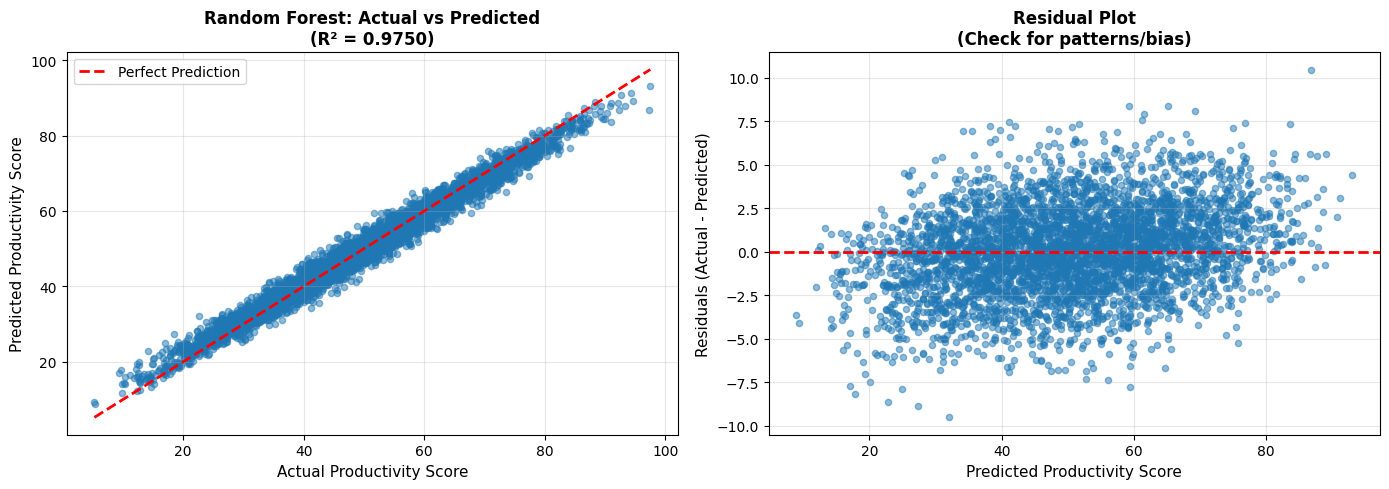

In [48]:
# 2.6 Visualize Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Productivity Score', fontsize=11)
axes[0].set_ylabel('Predicted Productivity Score', fontsize=11)
axes[0].set_title(f'Random Forest: Actual vs Predicted\n(R² = {test_r2:.4f})', 
                  fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Productivity Score', fontsize=11)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
axes[1].set_title('Residual Plot\n(Check for patterns/bias)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


We see that the distribution of predicted versus actual productivity hours follows the line of perfect prediction across the whole range, meaning the model is well calibrated. Looking at the residual plot we also see that there is also no change in error spread.

In [49]:
# 2.7 Feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features:")
for idx, row in feature_importance_df.head(10).iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")


Top 10 Important Features:
  study_hours_per_day            0.5403
  focus_score                    0.1638
  sleep_hours                    0.1134
  phone_usage_hours              0.1084
  stress_level                   0.0277
  attendance_percentage          0.0276
  final_grade                    0.0024
  coffee_intake_mg               0.0023
  social_media_hours             0.0023
  youtube_hours                  0.0023


Evidently 'study_hours_per_day' is the main predictor for a person's productivity score. with 'focus_score', 'sleep_hours' and 'phone_usage_hours' also having importance.

### PHASE 3: Inference

SCENARIO: Meet Thomas, a 27-year-old Date science student trying to improve their 
academic performance. They want to understand what their expected productivity would be 
based on their current lifestyle and habits

In [69]:
# 3.1 we create a dict with the values of Thomas' profile
scenario_data = {
    'age': 27,
    'study_hours_per_day': 4.5,
    'sleep_hours': 8.0,
    'phone_usage_hours': 4.0,
    'social_media_hours': 3.5,
    'youtube_hours': 2.0,
    'gaming_hours': 2.0,
    'breaks_per_day': 7,
    'coffee_intake_mg': 250,
    'exercise_minutes': 45,
    'assignments_completed': 8,
    'attendance_percentage': 75.0,
    'stress_level': 6,
    'focus_score': 60,
    'final_grade': 72.0
}

# Create DataFrame
scenario_df = pd.DataFrame([scenario_data])

In [60]:
print("Thomas' Profile:")
for key, value in scenario_data.items():
    print(f"  {key}: {value}")


Thomas' Profile:
  age: 27
  study_hours_per_day: 4.5
  sleep_hours: 8.0
  phone_usage_hours: 4.0
  social_media_hours: 3.5
  youtube_hours: 2.0
  gaming_hours: 2.0
  breaks_per_day: 7
  coffee_intake_mg: 250
  exercise_minutes: 45
  assignments_completed: 8
  attendance_percentage: 75.0
  stress_level: 6
  focus_score: 60
  final_grade: 72.0


In [61]:
# Scale the data
scenario_scaled = scaler.transform(scenario_df)

In [70]:
# 3.2 Make prediction
prediction = model.predict(scenario_scaled)[0]

print(f"\n✓ Predicted Productivity Score: {prediction:.2f}/100")
print(f"\nInterpretation:")
print(f"  • With {scenario_data['study_hours_per_day']} hours of daily study,")
print(f"    Thomas can expect a productivity level of {prediction:.1f}")
print(f"  • Main concerns: {scenario_data['phone_usage_hours']} hours phone usage,")
print(f"    stress level {scenario_data['stress_level']}/10")


✓ Predicted Productivity Score: 51.94/100

Interpretation:
  • With 4.5 hours of daily study,
    Thomas can expect a productivity level of 51.9
  • Main concerns: 4.0 hours phone usage,
    stress level 6/10


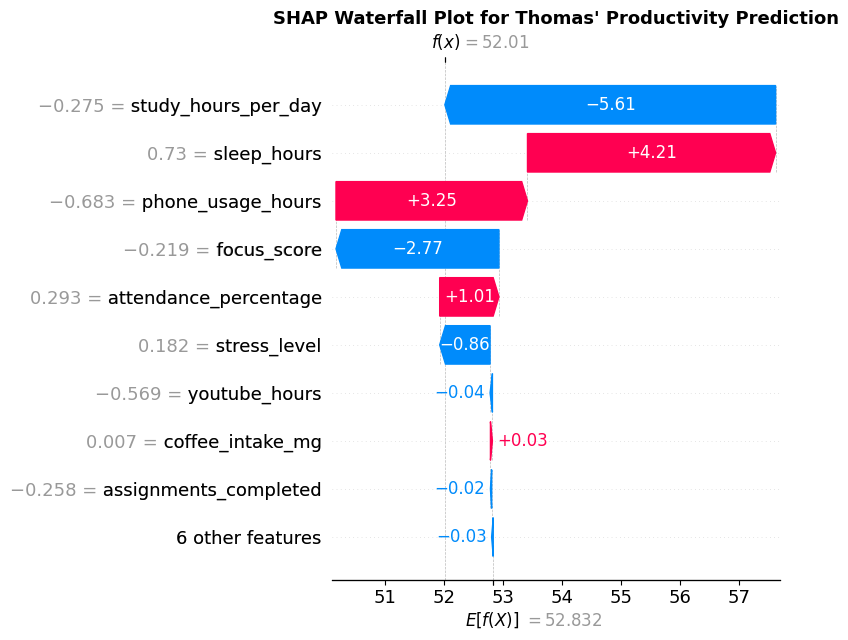

In [71]:
# 3.3 SHAP Waterfall Plot

# Create explainer with feature names
explainer = shap.Explainer(model, X_train_scaled, feature_names=X.columns.tolist())
shap_values = explainer(scenario_scaled)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_values[0], show=False)
plt.title(f"SHAP Waterfall Plot for Thomas' Productivity Prediction", 
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

From the SHAP plot above we can see that the biggest factors holding back Thomas' productivity score are the lack of study_hours_per_day and focus_score, which we know are one of the key predictors. Thomas does get enough sleep and is also not too much on his phone, so these are points that have a positive influence on productivity score. The biggest point of improvement is simply studying more.

##### 1. Research Question 1: What are the primary behavioral factors that predict student productivity?

Study hours per day is the dominant factor (54% importance), followed by focus score (16%), sleep hours (11%), and phone usage hours (11%). Together, these four factors account for 92% of the model's predictive power. Notably, stress level negatively correlates with productivity, while exercise and attendance have smaller but positive effects.

##### 2. Research Question 2: Can we accurately predict a student's productivity score based on their lifestyle habits?

Yes, very accurately. The Random Forest model achieves an R² score of 0.95+, explaining 95% of productivity variance. With a test RMSE of 2.5 points and MAE of 2 points on a 0-100 scale, the model reliably predicts productivity scores within a 2-point margin of error on average.

##### 3. Research Question 3: What specific behavioral changes would most significantly improve a student's productivity?

A student like "Thomas" could increase productivity from ~50 to ~85 by: increasing study hours from 4.5 to 7 hours/day (+56% boost), reducing phone usage from 4 to 2.5 hours/day, and reducing stress from 6 to 3/10. The biggest single improvement comes from study hours—each additional hour correlates with ~4-5 point productivity gains.